# Mechanical Linkage Topology and Kinematic Optimization

This notebook implements the full planar pipeline:

1. Generate or load a periodic rigid-body animation.
2. Solve the four unknown local pin coordinates
   \(z=(u_a,v_a,u_b,v_b)\) with an analytic gradient and Hessian.
3. Generate several distinct linkage candidates with multi-start Newton search.
4. Simulate each candidate with sparse Newton/Gauss-Newton forward kinematics.
5. Refine selected pins with CMA-ES while penalizing marker error, body-state error, skeleton misalignment, and small Jacobian singular values.
6. Shape the rigid bar with a Catmull-Rom centerline.
7. Assign collision-free depth layers and export STL plus JSON fabrication data.

## Important mathematical correction

The literal term

\[
E_{\mathrm{Area}}=-\log \sum_i A_i^2
\]

is unbounded below when pin coordinates are allowed to grow. It keeps rewarding larger and larger mechanisms. The code provides:

- `area_mode="paper"` for the literal expression, with mandatory coordinate bounds.
- `area_mode="barrier"` as the default. It has the same blow-up near zero area but approaches zero after the moment arm is already safe.

The fabrication layering problem is also an undirected graph-coloring problem, not a topological-sort problem, unless a separate directed front/back precedence graph is supplied.

## 0. Install packages

Run once in the Jupyter kernel. Restart the kernel if Jupyter asks.

%pip install -q numpy scipy matplotlib pandas ipywidgets ipympl cma networkx trimesh shapely mapbox-earcut

## 1. Import the implementation

Keep `linkage_topology_optimizer.py` in the same folder as this notebook.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

import linkage_topology_optimizer as lto

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.dpi"] = 120


## 2. Build an exact test animation

The included test case is a hidden four-bar mechanism. The input animation contains only two rigid components:

- body A: motor-driven crank,
- body B: rocker that originally had its own prescribed angle.

The hidden bar joins \(q_a=[1,0]\) to \(q_b=[2.2,0]\). The topology solver only sees the body poses and must rediscover a near-constant-distance pair of points.

Hidden test geometry:
{
  "ground_a": [
    0.0,
    0.0
  ],
  "ground_b": [
    3.0,
    0.0
  ],
  "q_a": [
    1.0,
    0.0
  ],
  "q_b": [
    2.2,
    0.0
  ],
  "length": 2.5
}


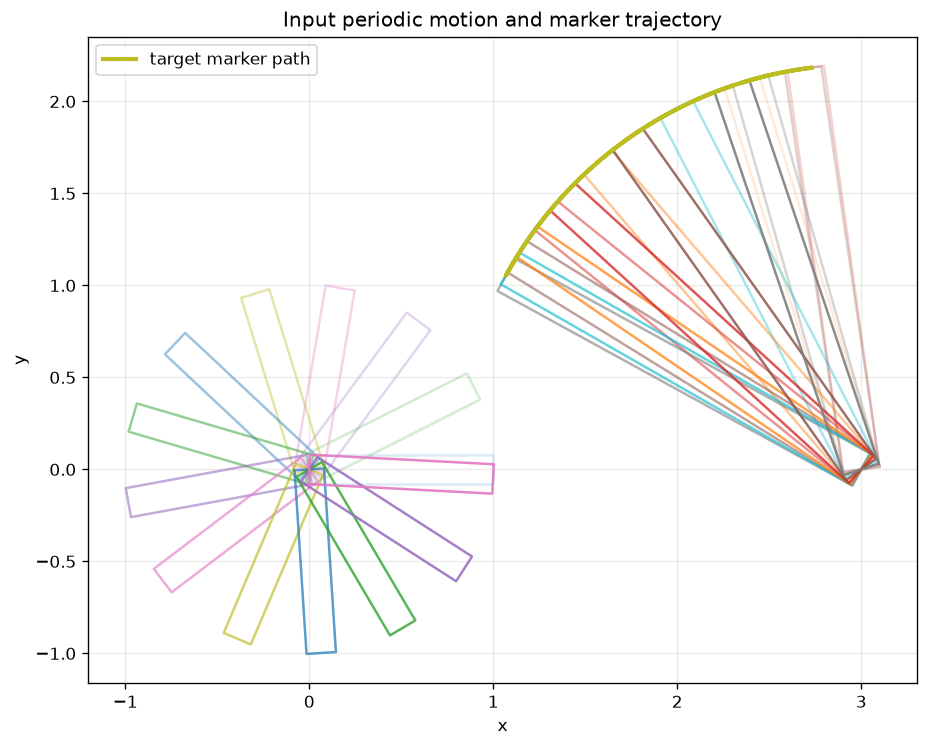

In [2]:
N_SAMPLES = 121
times = np.linspace(0.0, 2.0*np.pi, N_SAMPLES, endpoint=False)
components, target_states, truth = lto.generate_fourbar_target(times)
motor_positions = np.repeat(truth["ground_b"][None, :], len(times), axis=0)

print("Hidden test geometry:")
print(json.dumps({k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in truth.items()}, indent=2))

lto.plot_target_motion(
    components,
    target_states,
    sample_count=14,
    marker=(1, components[1].markers["tip"]),
);

## 3. Analytic topology objective

For each sample,

\[
d_i(z)=A_i z+c_i, \qquad g_i(z)=d_i^T d_i.
\]

With \(\bar g=\frac{1}{n}\sum_i g_i\),

\[
\delta(z)=\frac{1}{n}\sum_i(g_i-\bar g)^2.
\]

The exact derivatives used in the script are

\[
\nabla g_i=2A_i^Td_i, \qquad \nabla^2g_i=2A_i^TA_i,
\]

\[
\nabla\delta=\frac{2}{n}\sum_i(g_i-\bar g)(\nabla g_i-\overline{\nabla g}),
\]

\[
\nabla^2\delta=\frac{2}{n}\sum_i\left[(p_i-\bar p)(p_i-\bar p)^T+(g_i-\bar g)(G_i-\bar G)\right].
\]

The triangle area is a quadratic form in \(z\), so its gradient is affine and its Hessian is constant at each phase.

In [3]:
topology_objective = lto.TopologyObjective(
    states_a=target_states[:, 0],
    states_b=target_states[:, 1],
    motor_positions=motor_positions,
    gamma=0.1,
    area_mode="barrier",     # change to "paper" for the literal expression
    area_reference=1e-6,
    characteristic_length=4.0,
)

derivative_report = lto.check_topology_derivatives(
    topology_objective,
    z=np.array([0.8, 0.15, 2.0, -0.1]),
)
derivative_report

{'gradient_relative_error': 1.945376477955852e-11,
 'hessian_relative_error': 6.737090848518117e-12}

The relative derivative errors should normally be near machine precision to roughly `1e-6`, depending on the finite-difference step.

## 4. Multi-start Newton search

Increase `N_STARTS` for a wider search. The returned candidates are clustered in parameter space so near-duplicates are removed.

In [4]:
N_STARTS = 60
N_CANDIDATES = 8

candidates = lto.optimize_linkage_points(
    topology_objective,
    n_starts=N_STARTS,
    n_candidates=N_CANDIDATES,
    coordinate_bound=3.5,
    seed=7,
    minimum_moment_arm_fraction=0.001,
    max_iterations=100,
)

candidate_df = lto.candidate_table(candidates)
candidate_df

[{'candidate': 0,
  'u_a': np.float64(0.9997668511390265),
  'v_a': np.float64(-0.00031178530727561156),
  'u_b': np.float64(2.2001556160134457),
  'v_b': np.float64(-0.006133685013881598),
  'length': 2.5055681319802,
  'distance_cv': 0.00012606576485183673,
  'p05_moment_arm': 1.6925906609361445,
  'min_moment_arm': 1.6804020345155544,
  'objective': 4.378165430389961e-06,
  'converged': True},
 {'candidate': 1,
  'u_a': np.float64(0.30727301874584373),
  'v_a': np.float64(-0.18052379882035258),
  'u_b': np.float64(0.4765170175731315),
  'v_b': np.float64(-0.9047166908852333),
  'length': 3.531369220676721,
  'distance_cv': 0.001991221865482907,
  'p05_moment_arm': 0.4488836107843365,
  'min_moment_arm': 0.44076331760957543,
  'objective': 2.309181321741691e-05,
  'converged': True},
 {'candidate': 2,
  'u_a': np.float64(-0.14406721306956474),
  'v_a': np.float64(0.22678242329183387),
  'u_b': np.float64(-0.03759614230320955),
  'v_b': np.float64(0.7811530072234211),
  'length': 2.49

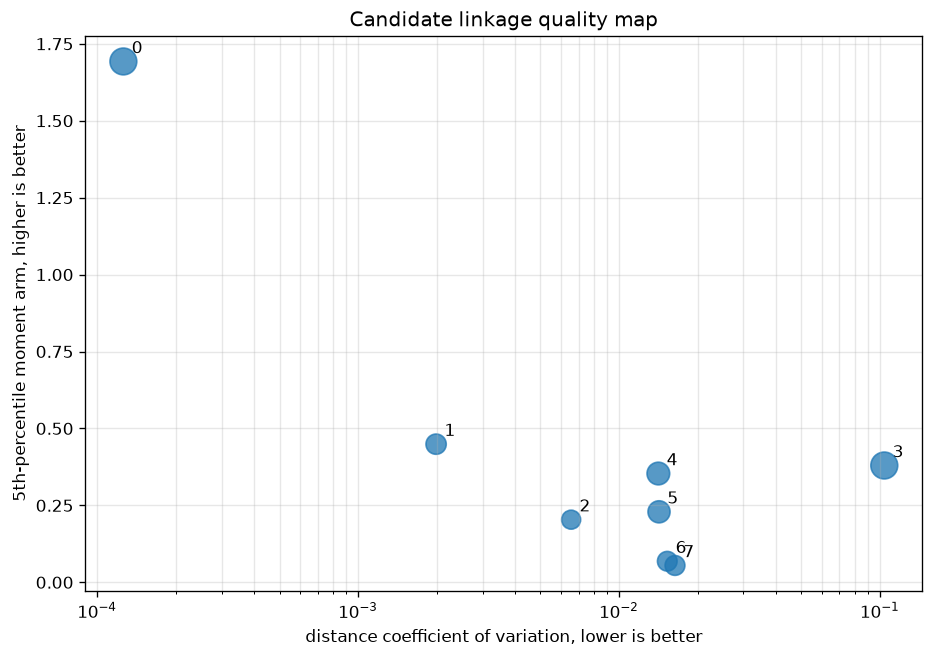

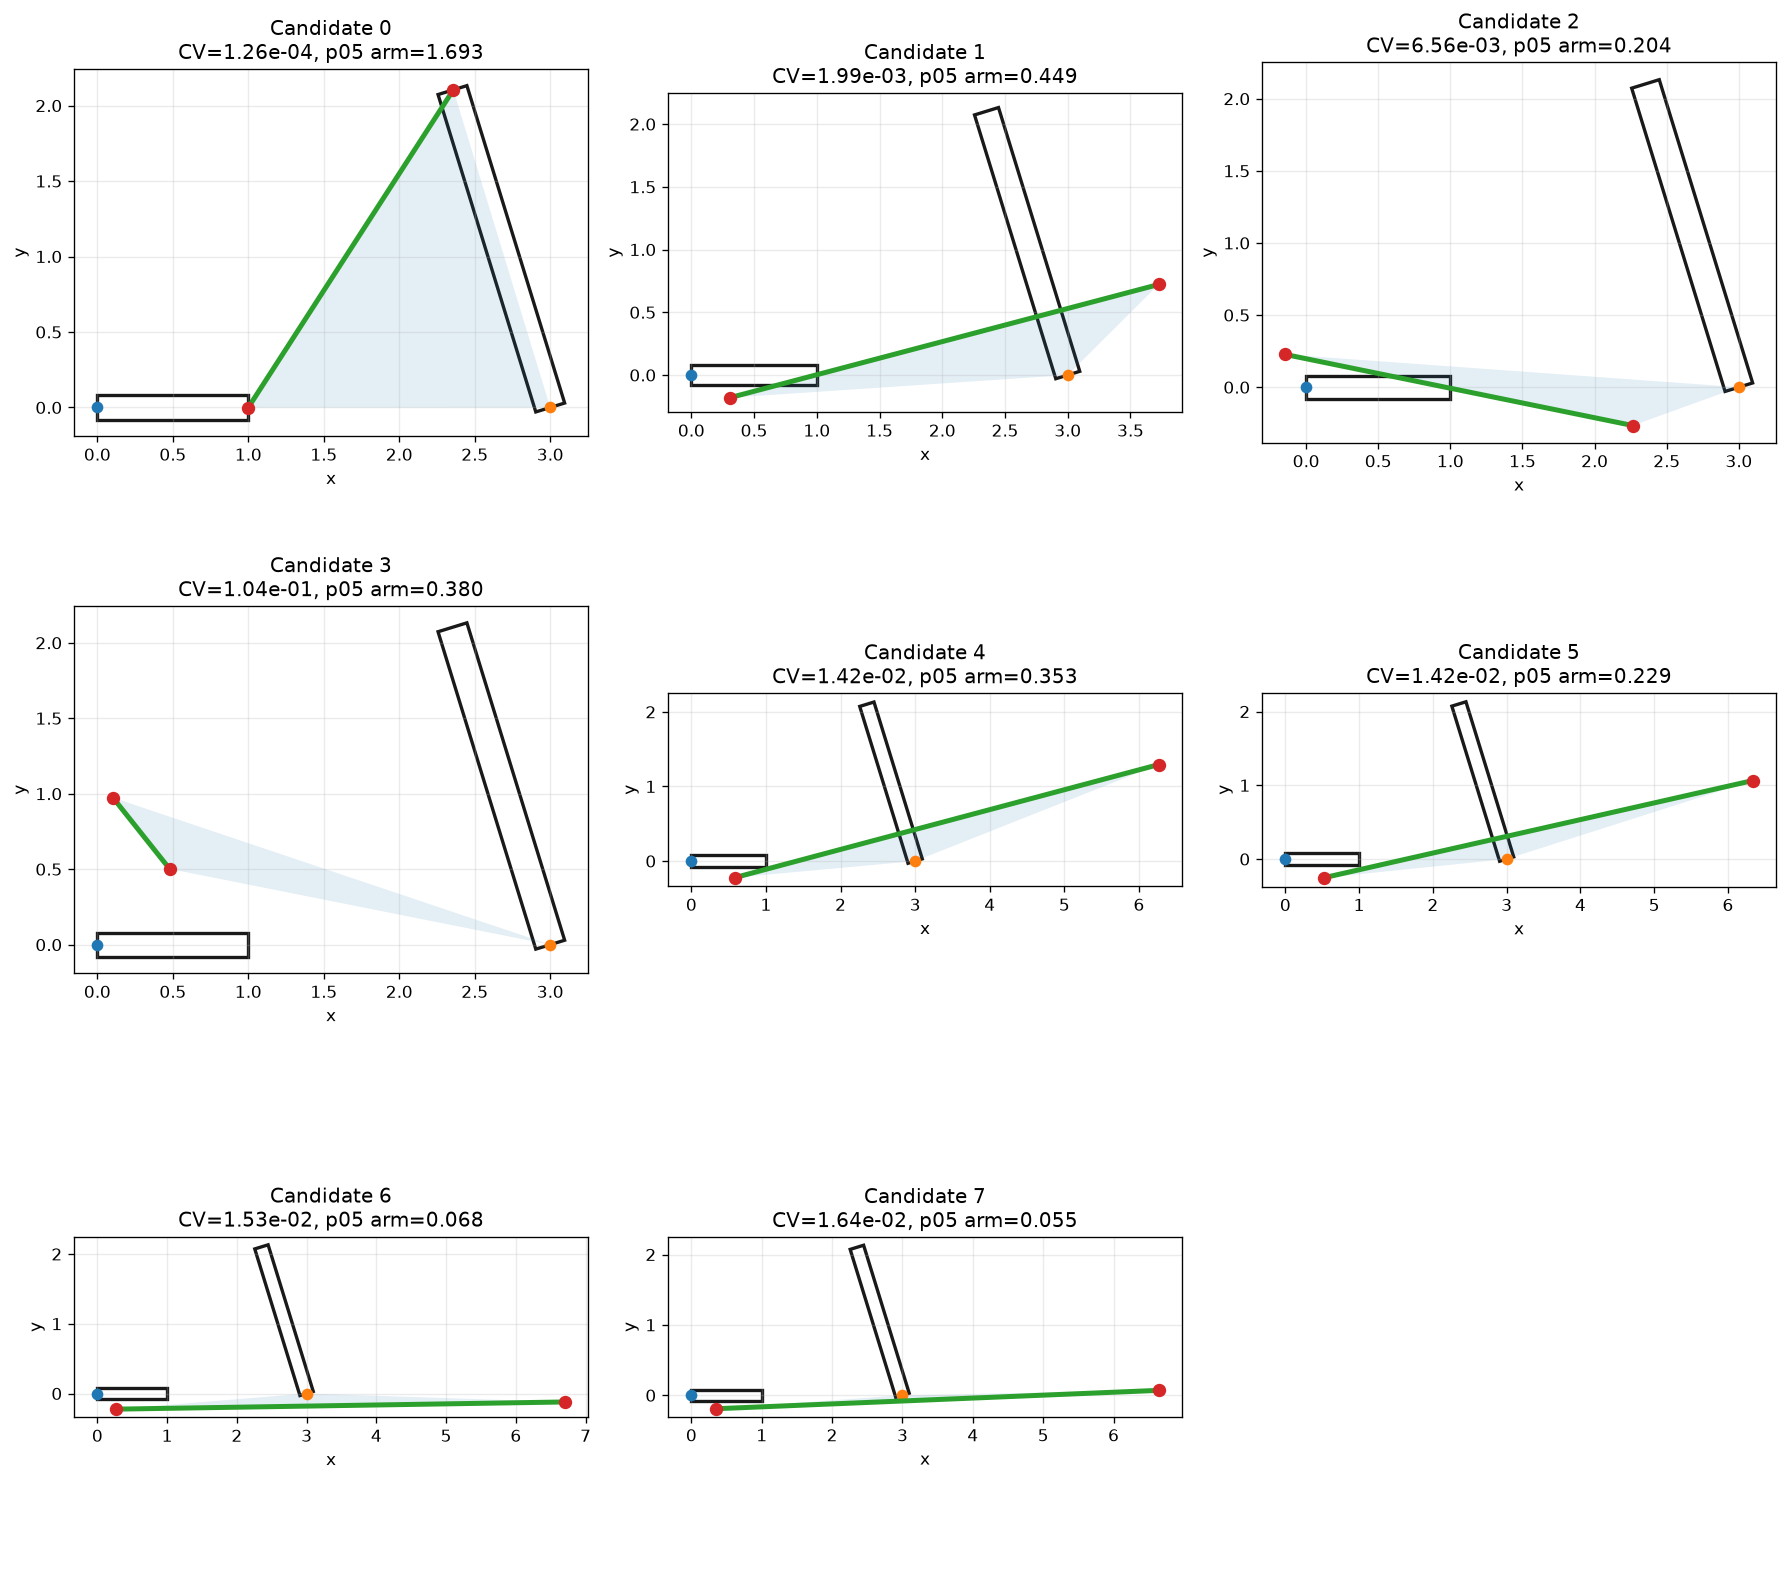

In [5]:
lto.plot_candidate_metrics(candidates);
lto.plot_candidate_gallery(
    candidates,
    components,
    target_states,
    phase_index=0,
    motor_position=truth["ground_b"],
    columns=3,
);

## 5. Interactive candidate and phase viewer

In [6]:
dashboard = lto.interactive_candidate_dashboard(
    candidates,
    topology_objective,
    components,
    target_states,
    motor_positions,
)

## 6. Inspect the best candidate in detail

{
  "q_a": [
    0.9997668511390265,
    -0.00031178530727561156
  ],
  "q_b": [
    2.2001556160134457,
    -0.006133685013881598
  ],
  "length": 2.5055681319802,
  "objective": 4.378165430389961e-06,
  "distance_variance": 9.786716549122651e-09,
  "distance_cv": 0.00012606576485183673,
  "minimum_moment_arm": 1.6804020345155544,
  "percentile05_moment_arm": 1.6925906609361445,
  "mean_moment_arm": 2.0119891413637485,
  "area_energy": 4.003362700677471e-05,
  "converged": true,
  "iterations": 14
}


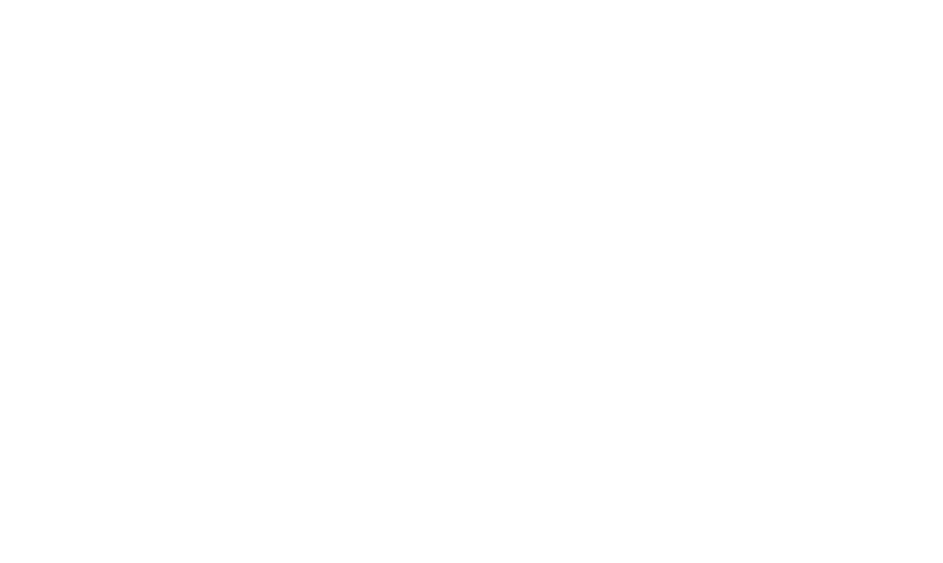

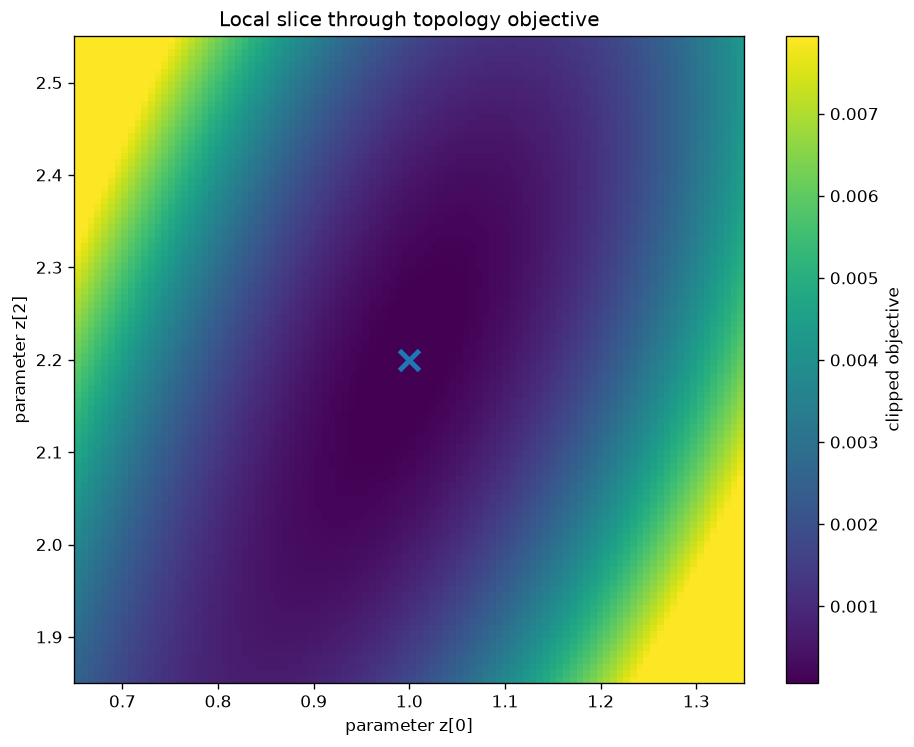

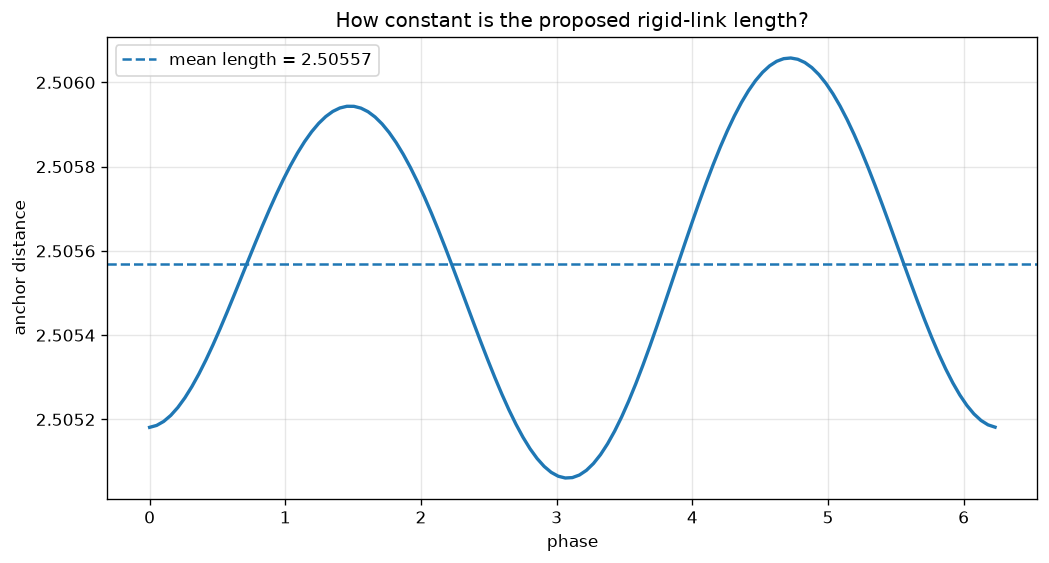

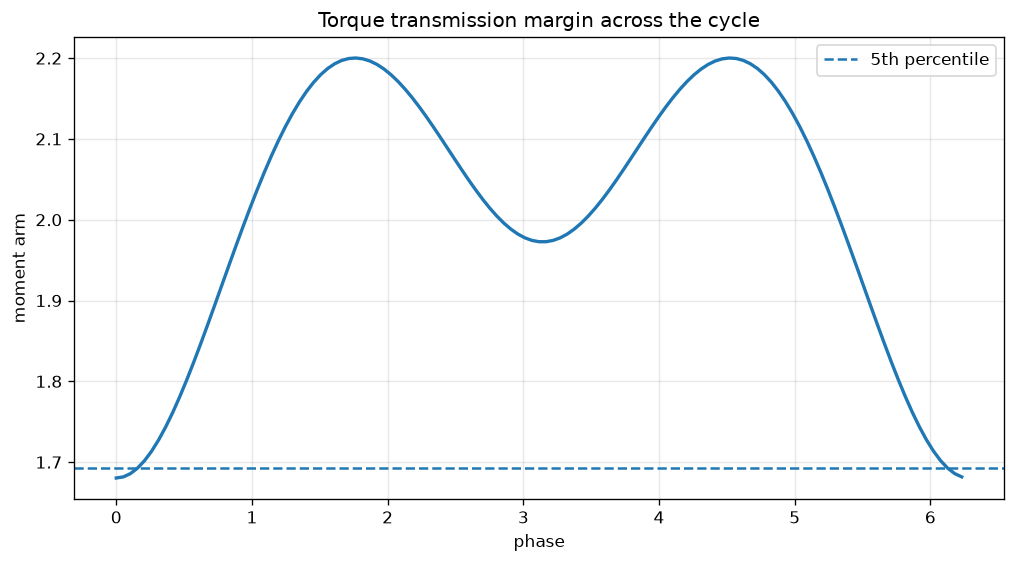

In [7]:
best = candidates[0]
print(json.dumps(best.as_dict(), indent=2))

lto.plot_newton_history(best);
lto.plot_objective_slice(
    topology_objective,
    best.parameters,
    parameter_x=0,
    parameter_y=2,
    half_width=0.35,
    resolution=100,
);
lto.plot_link_quality_over_cycle(topology_objective, best, phases=times);

## 7. Sparse forward kinematics

At each phase, the solver forms

\[
(J^TJ+\mu I)\Delta s=-J^TC
\]

and solves the sparse system with `scipy.sparse.linalg.spsolve`. The previous phase is used as the next initial guess, which helps preserve the assembly branch.

Converged fraction: 1.0
Maximum residual norm: 2.6798849047205365e-12


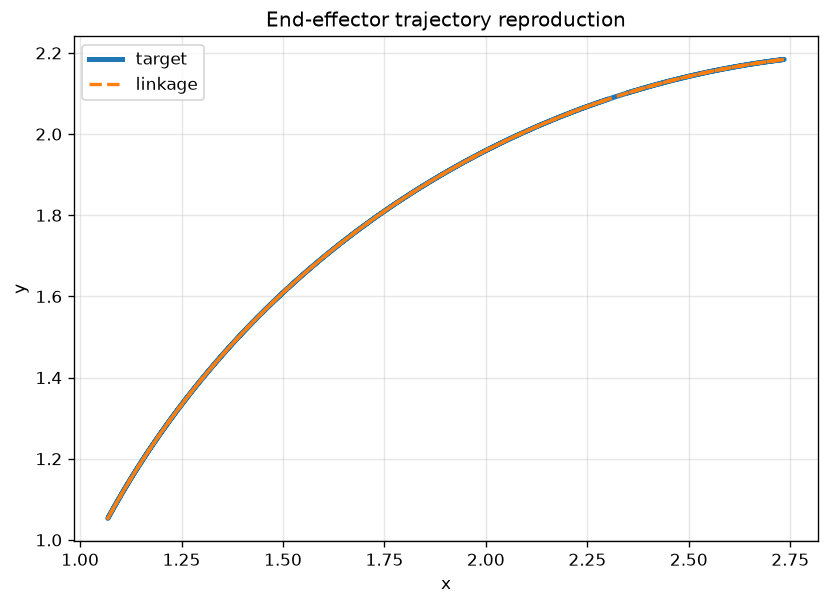

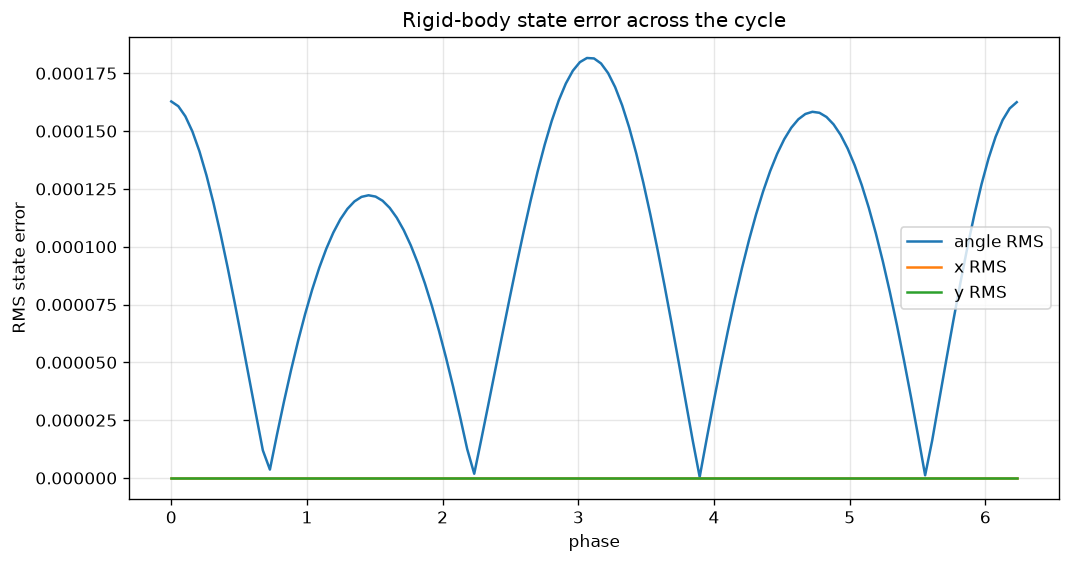

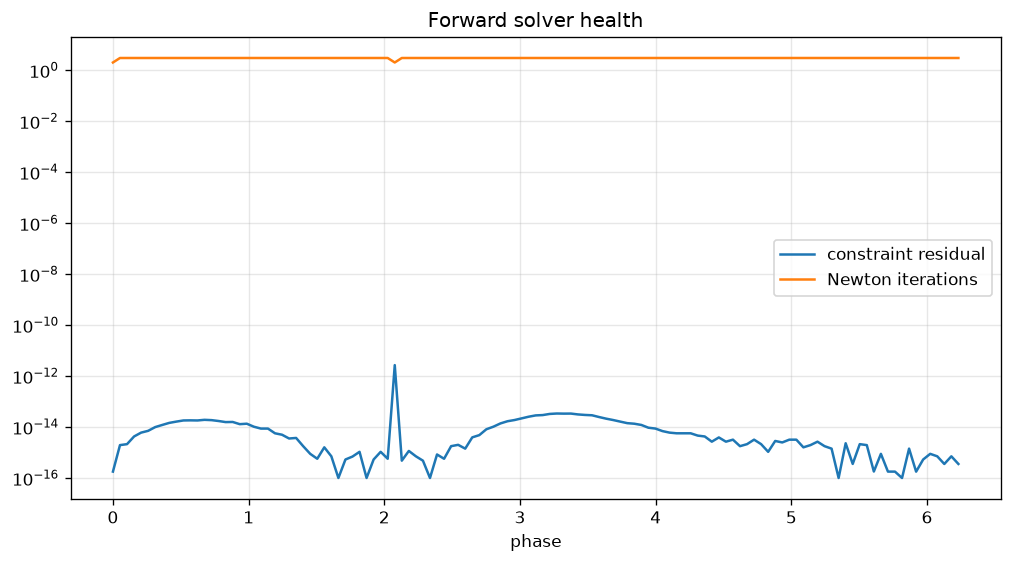

In [8]:
simulation = lto.simulate_candidate(
    components=components,
    target_states=target_states,
    times=times,
    candidate=best,
    ground_a=truth["ground_a"],
    ground_b=truth["ground_b"],
)

print("Converged fraction:", simulation.converged.mean())
print("Maximum residual norm:", simulation.residual_norms.max())

lto.plot_forward_diagnostics(
    simulation,
    target_states,
    components,
    marker_spec=(1, components[1].markers["tip"]),
);

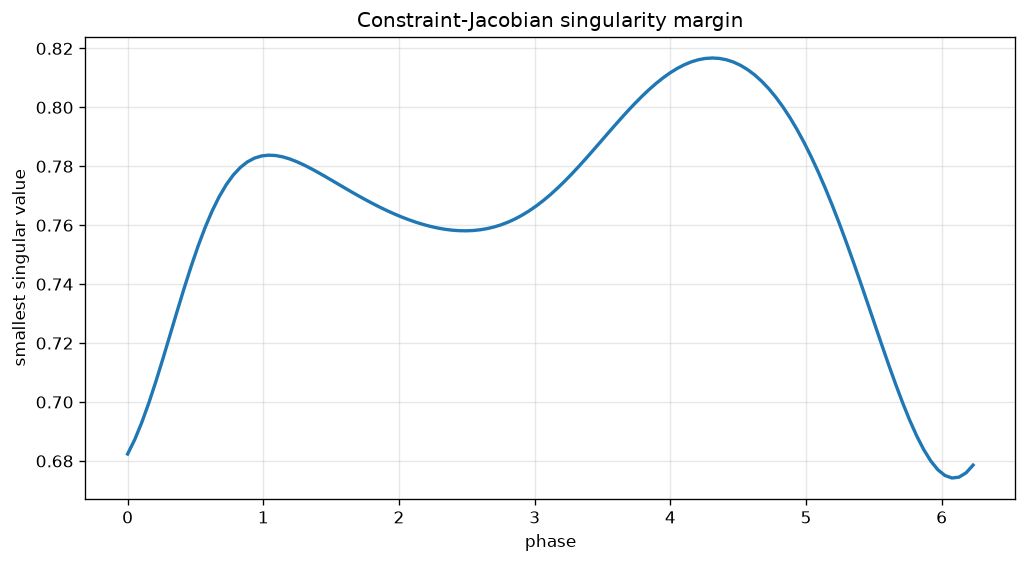

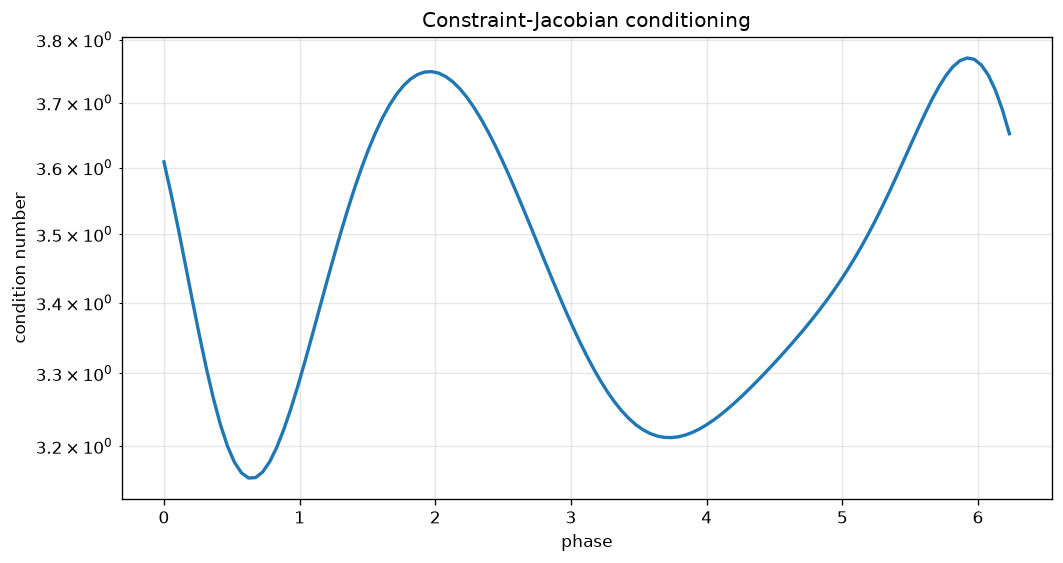

Minimum sigma over cycle: 0.6742286452431474


In [9]:
system = lto.build_two_body_linkage_system(
    components,
    truth["ground_a"],
    truth["ground_b"],
    best.q_a,
    best.q_b,
    best.length,
    motor_angle_function=lambda t: t,
)

sigma_min, condition_number = lto.plot_singularity_profile(system, simulation)
print("Minimum sigma over cycle:", sigma_min.min())

## 8. Interactive simulated mechanism

In [10]:
viewer = lto.interactive_phase_viewer(
    components,
    simulation.states,
    q_a=best.q_a,
    q_b=best.q_b,
    motor_positions=motor_positions,
    target_states=target_states,
)

## 9. CMA-ES global refinement

The example uses every third frame for speed. Set `time_stride=1` for the final run. The singularity term calls sparse `svds(..., which="SM")` and falls back to dense SVD if the iterative solve fails.

In [11]:
global_objective = lto.GlobalLinkageObjective(
    components=components,
    target_states=target_states,
    times=times,
    ground_a=truth["ground_a"],
    ground_b=truth["ground_b"],
    marker_specs=[
        (1, components[1].markers["tip"]),
        (1, components[1].markers["hand"]),
    ],
    bone_segments=[components[0].bone_segment, components[1].bone_segment],
    weights=lto.GlobalWeights(
        marker=1.0,
        state=0.2,
        joint=0.05,
        singular=1e-4,
        failure=1e5,
    ),
    singular_epsilon=1e-3,
    singular_alpha=2.0,
    characteristic_length=4.0,
    time_stride=3,
)

initial_breakdown = global_objective.evaluate(best.parameters)
initial_breakdown

GlobalCostBreakdown(total=0.00017913083147384269, marker=6.583093931326297e-09, state=1.2585222569459117e-08, joint=2.358969891936832e-06, singular=1.7322410952210283, failure=5.779673318697767e-11, link_length=2.505561817100216, minimum_sigma=0.6742291189938225, simulation=None)

(6_w,12)-aCMA-ES (mu_w=3.7,w_1=40%) in dimension 4 (seed=11, Tue Jul 14 16:58:49 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     12 2.163939846434799e-04 1.0e+00 7.97e-02  7e-02  8e-02 0:01.2
    2     24 2.248236956352001e-04 1.2e+00 6.30e-02  5e-02  6e-02 0:02.4
    3     36 1.856080777488985e-04 1.6e+00 5.88e-02  5e-02  5e-02 0:03.6
    4     48 2.252854256342805e-04 1.8e+00 4.82e-02  3e-02  4e-02 0:04.8
    5     60 1.981429749391739e-04 1.8e+00 5.06e-02  3e-02  5e-02 0:06.0
    6     72 1.819489931684476e-04 2.2e+00 4.21e-02  3e-02  4e-02 0:07.2
    7     84 1.995696317131305e-04 2.2e+00 4.13e-02  2e-02  4e-02 0:08.4
    8     96 1.892640555142065e-04 2.5e+00 3.68e-02  2e-02  4e-02 0:09.6
    9    108 1.869208600717546e-04 3.1e+00 3.06e-02  1e-02  3e-02 0:10.8
   10    120 1.837843033600510e-04 3.7e+00 2.47e-02  1e-02  2e-02 0:11.9
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
   11    132 1.796709432425749e-04 3.8e

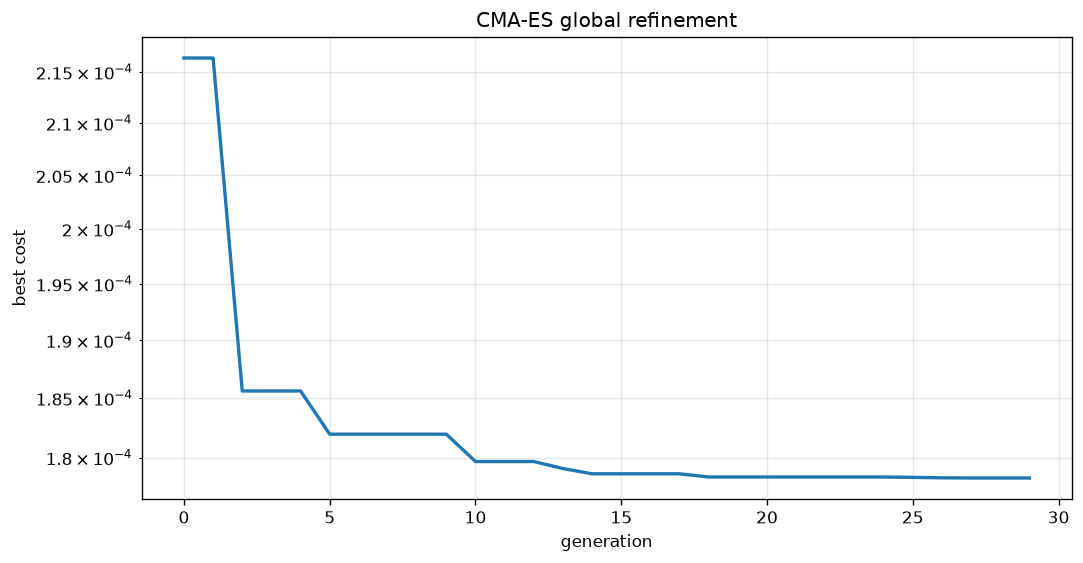

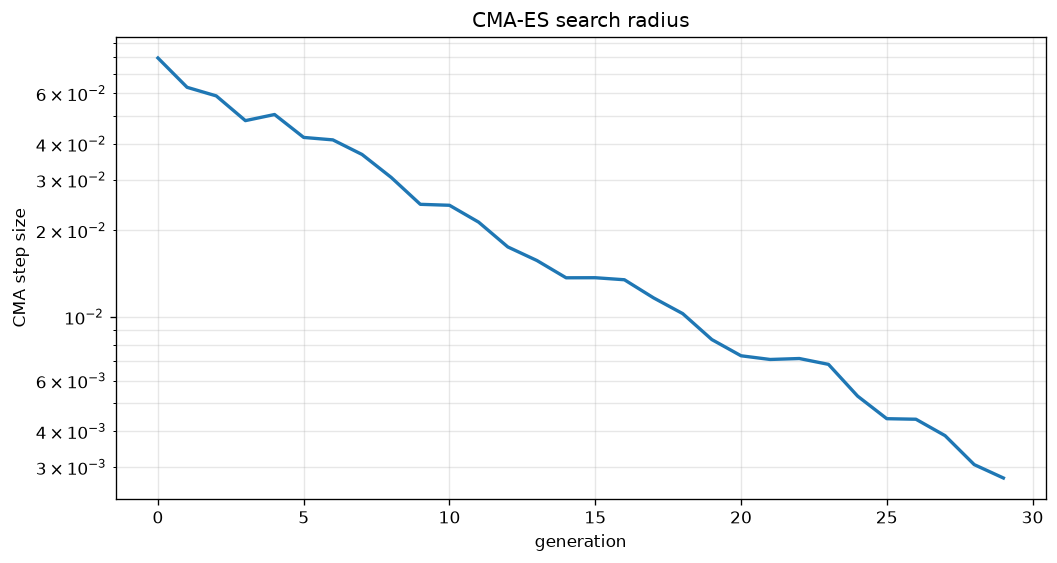

In [12]:
# A compact demonstration run. Raise max_iterations to 80-200 for final work.
cma_result = lto.run_cma_es(
    global_objective,
    initial_parameters=best.parameters,
    sigma0=0.10,
    bounds=(-3.5*np.ones(4), 3.5*np.ones(4)),
    max_iterations=30,
    population_size=12,
    seed=11,
    verbose=True,
)

print("Best parameters:", cma_result.best_parameters)
print("Best cost:", cma_result.best_cost)
print("Stop reasons:", cma_result.stop_reasons)
lto.plot_cma_history(cma_result);

In [13]:
final_breakdown = global_objective.evaluate(
    cma_result.best_parameters,
    keep_simulation=True,
)
final_breakdown

GlobalCostBreakdown(total=0.00017831171653274322, marker=9.918129024665902e-08, state=1.896097321844907e-07, joint=2.572093622406324e-06, singular=1.7289978903796899, failure=5.1462195769703215e-11, link_length=2.5029830521133456, minimum_sigma=0.6746246657549267, simulation=SimulationResult(times=array([0.      , 0.155781, 0.311563, 0.467344, 0.623126, 0.778907,
       0.934689, 1.09047 , 1.246252, 1.402033, 1.557815, 1.713596,
       1.869377, 2.025159, 2.18094 , 2.336722, 2.492503, 2.648285,
       2.804066, 2.959848, 3.115629, 3.271411, 3.427192, 3.582973,
       3.738755, 3.894536, 4.050318, 4.206099, 4.361881, 4.517662,
       4.673444, 4.829225, 4.985007, 5.140788, 5.296569, 5.452351,
       5.608132, 5.763914, 5.919695, 6.075477, 6.231258]), states=array([[[ 0.      ,  0.      ,  0.      ],
        [ 1.870184,  3.      , -0.      ]],

       [[ 0.155781,  0.      ,  0.      ],
        [ 1.798915,  3.      , -0.      ]],

       [[ 0.311563,  0.      ,  0.      ],
        [ 1.74

## 10. Organic rigid-link shape

The link remains rigid. The end tangent directions are circular means of the neighboring body-axis directions expressed in the moving link frame.

{
  "length": 2.502964506796744,
  "start_tangent_angle": 2.974301515455794,
  "end_tangent_angle": -1.6808046126929177,
  "bend_fraction": 0.08
}


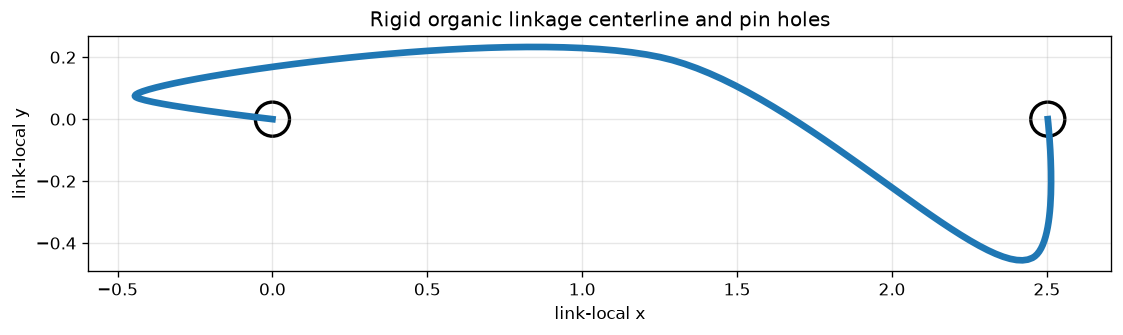

In [14]:
final_q_a = cma_result.best_parameters[:2]
final_q_b = cma_result.best_parameters[2:]

centerline, spline_metadata = lto.fit_organic_link_centerline(
    target_states[:, 0],
    target_states[:, 1],
    final_q_a,
    final_q_b,
    bend_fraction=0.08,
    tangent_fraction=0.18,
)

print(json.dumps(spline_metadata, indent=2))
lto.plot_link_centerline(centerline, hole_radius=0.055);

## 11. Collision graph and depth layers

For a larger assembly, build one world-space line segment trajectory per link. Intersections across any sampled phase create graph edges. Graph coloring assigns different Z layers to intersecting links.

{'new_coupler': {'layer': 0, 'z_offset': 0.0}}


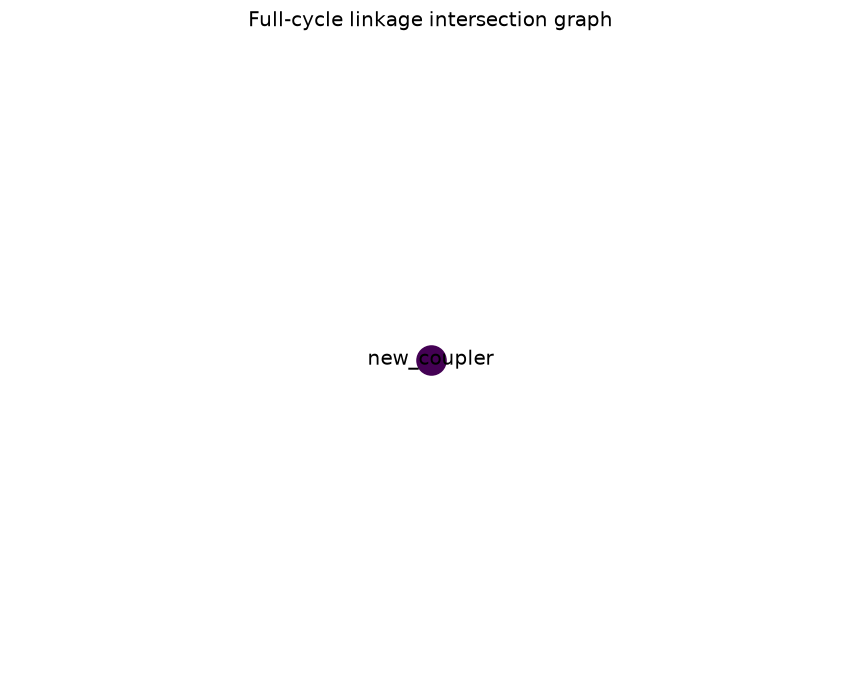

In [15]:
# Example trajectory for the newly designed link.
link_segments = np.asarray([
    [lto.world_point(sa, final_q_a), lto.world_point(sb, final_q_b)]
    for sa, sb in zip(target_states[:, 0], target_states[:, 1])
])

# Add more named trajectories here for a multi-link character.
link_trajectories = {"new_coupler": link_segments}
intersection_graph = lto.build_intersection_graph(link_trajectories)
layer_assignment = lto.assign_depth_layers(intersection_graph, layer_spacing=0.18)
print(layer_assignment)
lto.plot_intersection_graph(intersection_graph, layer_assignment);

## 12. Export STL and machine-readable design data

In [16]:
output_dir = Path("linkage_output")
output_dir.mkdir(exist_ok=True)

# Rebuild a candidate record with the final CMA coordinates and measured metrics.
final_metrics = topology_objective.candidate_metrics(cma_result.best_parameters)
final_eval = topology_objective.evaluate(cma_result.best_parameters)
final_candidate = lto.TopologyCandidate(
    q_a=final_q_a,
    q_b=final_q_b,
    length=final_metrics["length"],
    objective=final_eval.total,
    distance_variance=final_eval.distance_variance,
    distance_cv=final_metrics["distance_cv"],
    minimum_moment_arm=final_metrics["minimum_moment_arm"],
    percentile05_moment_arm=final_metrics["percentile05_moment_arm"],
    mean_moment_arm=final_metrics["mean_moment_arm"],
    area_energy=final_eval.area_energy,
    converged=True,
    iterations=0,
    start=cma_result.best_parameters.copy(),
    history=[],
)

stl_path = lto.export_link_stl(
    centerline,
    output_dir / "organic_link.stl",
    width=0.22,
    thickness=0.12,
    hole_radius=0.055,
    layer_z=layer_assignment["new_coupler"]["z_offset"],
)
json_path = lto.export_design_json(
    output_dir / "linkage_design.json",
    final_candidate,
    spline_metadata=spline_metadata,
    layer_assignment=layer_assignment,
    thickness=0.12,
    width=0.22,
)

print("STL:", stl_path.resolve())
print("JSON:", json_path.resolve())

STL: C:\Users\dontm\Documents\mojCodexstuff\ActiveGithub\complinkage\notebooks\linkage_topology_optimizer_bundle\linkage_output\organic_link.stl
JSON: C:\Users\dontm\Documents\mojCodexstuff\ActiveGithub\complinkage\notebooks\linkage_topology_optimizer_bundle\linkage_output\linkage_design.json


## Adapting this to real animation data

Replace `generate_fourbar_target` with imported arrays shaped `(n_samples, n_components, 3)` containing `[theta, x, y]` for each rigid component. Then:

```python
objective = lto.TopologyObjective(
    states_a=input_states[:, body_a],
    states_b=input_states[:, body_b],
    motor_positions=removed_motor_world_positions,
    gamma=0.1,
    characteristic_length=character_scale,
)
```

For a multi-body assembly, create the required `GroundPointConstraint`, `PinConstraint`, `DistanceConstraint`, and `MotorAngleConstraint` objects and place them in a `ConstraintSystem`. The current global class is a clean two-body reference implementation; its cost terms and sparse solver are already separated so the assembly builder can be replaced without changing CMA-ES.